In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# After mounting, you can find your folder path in the file explorer on the left.
# Typically it looks something like:
# folder_path = '/content/drive/MyDrive/CS166 Datasets'

# Example to list CSV files in a directory:
# import os
# import glob
# csv_files = glob.glob(os.path.join(folder_path, '*.csv'))
# print(csv_files)

Mounted at /content/drive


# Phishing Email Detection Pipeline

This notebook builds a machine learning pipeline to detect phishing emails using natural language processing (NLP) and scikit-learn. It covers data loading, text preprocessing, exploratory data analysis, feature extraction, and model evaluation.

## 1. Data Loading
Load the dataset from the mounted Google Drive. Update the filename or column names if necessary.

In [ ]:
import pandas as pd
import os

# Define the path to the dataset
dataset_path = '/content/drive/MyDrive/CS166 Datasets/phishing_email.csv'

# Load the dataset
# Note: Update the column names below if your dataset uses different names for the text and label columns.
try:
    df = pd.read_csv(dataset_path)
    print("Dataset loaded successfully!")
    display(df.head())

    # Example of renaming columns if they aren't 'text' and 'label'
    # df = df.rename(columns={'Email Text': 'text', 'Email Type': 'label'})

except FileNotFoundError:
    print(f"Error: Could not find the file at {dataset_path}. Please check the filename.")

Dataset loaded successfully!


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


## 2. Preprocessing
Clean the email text by converting to lowercase, removing URLs, stripping punctuation, and removing extra whitespace.

In [ ]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""

    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)

    # 4. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Standardize the column name if it's 'text_combined'
if 'text_combined' in df.columns:
    df = df.rename(columns={'text_combined': 'text'})

# Apply preprocessing to the text column
if 'text' in df.columns:
    df['clean_text'] = df['text'].apply(clean_text)
    print("Preprocessing complete.")
    display(df[['text', 'clean_text']].head(3))
else:
    print("Column 'text' not found. Please verify your column names.")

Preprocessing complete.


,text,clean_text
0,hpl nom may 25 2001 see attached file hplno 52...,hpl nom may 25 2001 see attached file hplno 52...
1,nom actual vols 24 th forwarded sabrae zajac h...,nom actual vols 24 th forwarded sabrae zajac h...
2,enron actuals march 30 april 1 201 estimated a...,enron actuals march 30 april 1 201 estimated a...


## 3. Exploratory Data Analysis (EDA)
Analyze the class distribution and view some sample messages.

Dataset shape: (82486, 3)

Class distribution:
 label
1    42891
0    39595
Name: count, dtype: int64


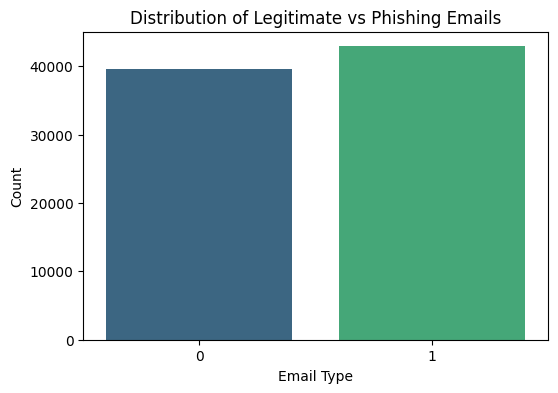


--- Sample Legitimate Email ---
hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls

--- Sample Phishing Email ---
link dwl g 510 802 11 g wireless pci lan adapter 39 85 39 85 dwl g 510 high speed 2 4 ghz 802 11 g wireless pci lan adapter ieee 802 11 g standardupto 54 mbpsoperating frequency range 2 4 ghz ideal solution enabling wireless networking capabilities desktops pcs home office dwl g 510 visit http www computron com deals link dwl g 510 802 11 g wireless pci lan adapter link g 510 wireless pci adapter featuring latest ieee 802 11 g wireless technology deliverincredibly fast data transfer 2 4 ghz freq


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming the label column is named 'label' (e.g., 'phishing' and 'legitimate' or 1 and 0)
if 'label' in df.columns:
    # Basic statistics
    print("Dataset shape:", df.shape)
    print("\nClass distribution:\n", df['label'].value_counts())

    # Plot class distribution
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x='label', hue='label', palette='viridis', legend=False)
    plt.title('Distribution of Legitimate vs Phishing Emails')
    plt.xlabel('Email Type')
    plt.ylabel('Count')
    plt.show()

    # Print sample messages
    print("\n--- Sample Legitimate Email ---")
    print(df[df['label'] == df['label'].unique()[0]]['clean_text'].iloc[0][:500])
    print("\n--- Sample Phishing Email ---")
    print(df[df['label'] == df['label'].unique()[1]]['clean_text'].iloc[0][:500])
else:
    print("Column 'label' not found. Please verify your column names.")

## 4. Feature Extraction & 5. Train/Test Split
Convert the cleaned text into numerical TF-IDF features and split the data (80% training, 20% testing).

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Initialize TF-IDF Vectorizer with a maximum of 5000 features
tfidf = TfidfVectorizer(max_features=5000)

# Extract features (X) and labels (y)
X = tfidf.fit_transform(df['clean_text']).toarray()
y = df['label'].values

# Split the dataset: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")

Training set size: 65988 samples
Testing set size: 16498 samples
Number of features: 5000


## 6. Model Training & 7. Evaluation
Train Multinomial Naive Bayes and Logistic Regression models. Evaluate them using accuracy, precision, recall, f1-score, and confusion matrices.


Multinomial Naive Bayes Evaluation
Accuracy: 0.9624

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      7919
           1       0.98      0.95      0.96      8579

    accuracy                           0.96     16498
   macro avg       0.96      0.96      0.96     16498
weighted avg       0.96      0.96      0.96     16498



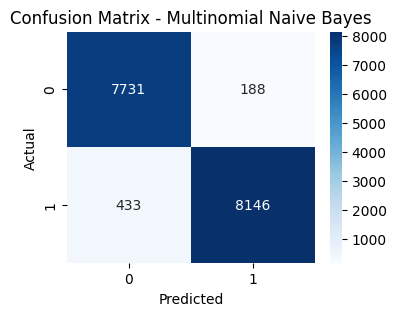


Logistic Regression Evaluation
Accuracy: 0.9826

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7919
           1       0.98      0.99      0.98      8579

    accuracy                           0.98     16498
   macro avg       0.98      0.98      0.98     16498
weighted avg       0.98      0.98      0.98     16498



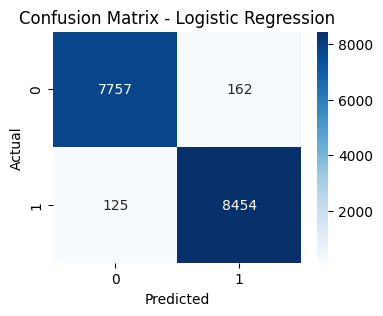

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Train Multinomial Naive Bayes ---
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

# --- Train Logistic Regression ---
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# Helper function to evaluate and plot
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n{'='*40}\n{model_name} Evaluation\n{'='*40}")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}\n")
    print("Classification Report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Evaluate both models
evaluate_model(y_test, nb_preds, "Multinomial Naive Bayes")
evaluate_model(y_test, lr_preds, "Logistic Regression")

## 8. Compare Models & 9. Prediction Function
Define a custom prediction function that outputs the label and confidence score.

In [ ]:
def predict_email(text, model, vectorizer):
    """
    Predicts whether an email is phishing or legitimate.
    Returns the predicted label and the confidence score (probability).
    """
    # Preprocess the custom text
    cleaned = clean_text(text)
    # Transform using the fitted TF-IDF vectorizer
    features = vectorizer.transform([cleaned]).toarray()

    # Get prediction and probabilities
    pred_label = model.predict(features)[0]
    probs = model.predict_proba(features)[0]

    # Confidence is the probability of the predicted class
    confidence = max(probs) * 100

    return pred_label, confidence

print("Prediction function ready. We will use the Logistic Regression model for the demo.")

Prediction function ready. We will use the Logistic Regression model for the demo.


## 10. Demonstration
Test the prediction function on three distinct examples: clearly phishing, clearly legitimate, and ambiguous.

In [ ]:
# 1. Clearly Phishing Example
phishing_demo = """
URGENT: Your account has been compromised! Please click the link below immediately to verify your identity and reset your password.
Failure to do so will result in account suspension. http://secure-update-account.com/login
"""

# 2. Clearly Legitimate Example
legitimate_demo = """
Hi Team,
Just a reminder that we have our weekly sync at 10 AM tomorrow in the main conference room.
Please review the attached agenda before the meeting.
Best,
John
"""

# 3. Ambiguous Example
ambiguous_demo = """
Hello,
I found your resume online and think you'd be a great fit for a remote position we have available.
Pay is $500/day. Please reply if you are interested in hearing more details.
Thanks,
Recruiter
"""

# Test the examples
examples = [("Phishing", phishing_demo), ("Legitimate", legitimate_demo), ("Ambiguous", ambiguous_demo)]

for demo_type, text in examples:
    label, confidence = predict_email(text, lr_model, tfidf)
    print(f"--- {demo_type} Example ---")
    print(f"Text snippet: {text[:100]}...")
    print(f"Prediction: {label} (Confidence: {confidence:.2f}%)\n")

--- Phishing Example ---
Text snippet: 
URGENT: Your account has been compromised! Please click the link below immediately to verify your i...
Prediction: 1 (Confidence: 99.44%)

--- Legitimate Example ---
Text snippet: 
Hi Team,
Just a reminder that we have our weekly sync at 10 AM tomorrow in the main conference room...
Prediction: 0 (Confidence: 98.33%)

--- Ambiguous Example ---
Text snippet: 
Hello,
I found your resume online and think you'd be a great fit for a remote position we have avai...
Prediction: 1 (Confidence: 63.82%)



In [ ]:
## 11. Save Model & Vectorizer
# Run this after training to export, then download both files.
import joblib
from google.colab import files

joblib.dump(lr_model, "lr_model.pkl")
joblib.dump(tfidf,    "tfidf.pkl")

files.download("lr_model.pkl")
files.download("tfidf.pkl")
print("Done - two .pkl files downloaded.")

## 12. Train SGDClassifier for Incremental Learning
SGDClassifier supports `partial_fit` so the backend can update the model from user feedback without a full retrain.

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
import joblib
from google.colab import files

sgd_model = SGDClassifier(loss="log_loss", max_iter=1000, random_state=42)
sgd_model.fit(X_train, y_train)

sgd_preds = sgd_model.predict(X_test)
print(f"SGDClassifier Accuracy: {accuracy_score(y_test, sgd_preds):.4f}")

joblib.dump(sgd_model, "sgd_model.pkl")
files.download("sgd_model.pkl")
print("Done - place sgd_model.pkl in backend/models/")